In [1]:
library(dplyr)
library(biomaRt)
library(stringr)
library(org.Mm.eg.db)
library(AnnotationDbi)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading

In [2]:
data <- readRDS("/mnt/lareaulab/reliscu/projects/Chronocell/data/janssens_2025_preprint/GSE279232_seuratObj_VBO_4-12.rds")

## Map gene and protein identfiers

In [278]:
antibods <- rownames(data$ADT)
antibods_matched <- antibods[toupper(antibods) %in% toupper(rownames(data$RNA))]

In [279]:
normalize_marker <- function(x){
  x <- str_replace_all(x, "^'+|'+$", "")
  x <- str_trim(x)

  # remove vendor/isotype/clone suffixes ONLY (keep biology parts like CD16-CD32, IA-IE, F4-80)
  x <- str_replace(x, "-(mh|Mouse-[A-Za-z]+|Rat-[A-Za-z]+|Hamster|A\\d+)$", "")

  # normalize common CD capitalization for matching
  ifelse(str_detect(x, "^CD\\d"), str_to_upper(x), x)
}

# ## things we should NOT split even though they have "-"
# do_not_split <- c("F4-80", "IA-IE", "Ly6A-Ly6E", "LY6A-LY6E", "CD45R-B220")

# ## split only CD##-CD## combos
# split_combo <- function(x){
#   if (x %in% do_not_split) return(x)
#   if (str_detect(x, "^CD\\d+-CD\\d+$")) unlist(str_split(x, "-", n = 2)) else x
# }


In [280]:
antibods_unmatched <- antibods[!antibods %in% antibods_matched]
antibods_clean <- normalize_marker(antibods_unmatched)

In [281]:
df <- data.frame(Orig_ID=antibods_unmatched, ID_clean=antibods_clean)

In [282]:
mart <- useEnsembl(
  biomart="genes",
  dataset="mmusculus_gene_ensembl",
  mirror="useast"
)

# Map synonyms -> mouse gene symbol
bm <- getBM(
  attributes=c("external_synonym", "mgi_symbol"),
  filters="external_synonym",
  values=df$ID_clean,
  mart=mart
) %>%
  distinct() %>%
  arrange(mgi_symbol, external_synonym)

In [283]:
df_mapped <- merge(x=df, y=bm, by.x="ID_clean", by.y="external_synonym", all.x=TRUE)

In [284]:
df_unmapped <- df_mapped %>% filter(is.na(mgi_symbol))

In [285]:
cols_want <- intersect(c("ALIAS","SYMBOL"), columns(org.Mm.eg.db))

map <- AnnotationDbi::select(
  org.Mm.eg.db,
  keys=df_unmapped$ID_clean,
  keytype="ALIAS",
  columns=cols_want
) |> distinct()

'select()' returned many:many mapping between keys and columns



In [286]:
df_mapped <- merge(df_mapped, map, by.x="ID_clean", by.y="ALIAS", all.x=TRUE)

In [287]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$mgi_symbol[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "mgi_symbol"]

In [288]:
df_unmapped <- df_mapped %>% filter(is.na(SYMBOL))

In [289]:
mg_res <- mygene::queryMany(
  unique(df_unmapped$ID_clean),
  scopes=c("alias","symbol","name"),
  fields=c("symbol","alias"),
  species="mouse",
  returnall=TRUE
)
mg_res_df <- data.frame(mg_res$response) %>% arrange(symbol)

Finished


In [290]:
df_mapped <- merge(df_mapped, mg_res_df, by.x="ID_clean", by.y="query", all.x=TRUE)

In [291]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$symbol[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "symbol"]

In [292]:
df_unmapped <- df_mapped %>% filter(is.na(SYMBOL))

In [293]:
library(dplyr)
library(tidyr)
library(purrr)
library(stringr)
library(AnnotationDbi)
library(org.Mm.eg.db)

## Make Jupyter show *all* rows/cols for plain data.frames too
options(
  repr.data.frame.max.rows = Inf,
  repr.data.frame.max.cols = Inf,
  repr.matrix.max.rows     = Inf,
  repr.matrix.max.cols     = Inf
)

symbols_all <- keys(org.Mm.eg.db, keytype = "SYMBOL")
sym_like <- function(rx) str_subset(symbols_all, regex(rx))

## 1) Multi-target / multi-subunit / “combo marker” expansions
multi_marker_map <- tibble::tribble(
  ~ID_clean,        ~SYMBOLS,
  "CD16-CD32",      list(c("Fcgr3", "Fcgr2b")),                  # CD16/32 antibody targets both :contentReference[oaicite:3]{index=3}
  "IA-IE",          list(c("H2-Aa","H2-Ab1","H2-Ea","H2-Eb1")),   # MHC-II I-A + I-E subunits :contentReference[oaicite:4]{index=4}
  "Ly6A-Ly6E",      list(c("Ly6a", "Ly6e")),
  "CD300C-D",       list(c("Cd300c", "Cd300c2")),                # vendor lists Gene IDs 387565/140497 :contentReference[oaicite:5]{index=5}
  "PIRA-PIRB",      list(c("Pirb", sym_like("^Pira")))           # Pirb + the Pira* family (cluster)
) %>%
  mutate(SYMBOLS = map(SYMBOLS, ~ unique(.x[!is.na(.x) & nzchar(.x)])))

## 2) “Family” markers (TCR variable-region families): expand to all matching genes
family_marker_regex <- c(
  "TCRb5" = "^Trbv5",
  "TCRb8" = "^Trbv8",
  "TCRg2" = "^Trgv2",
  "TCRg3" = "^Trgv3"
)

family_map <- imap_dfr(family_marker_regex, \(rx, id) {
  tibble(ID_clean = id, SYMBOLS = list(sym_like(rx)))
}) %>%
  filter(lengths(SYMBOLS) > 0)

multi_marker_map <- bind_rows(multi_marker_map, family_map) %>%
  group_by(ID_clean) %>%
  summarise(SYMBOLS = list(unique(unlist(SYMBOLS))), .groups = "drop")

## 3) Merge into your existing mapping results
## Assumes you already have `map` with columns: ID_clean and SYMBOL (and anything else you want to keep)
map2 <- df_unmapped %>%
  left_join(multi_marker_map, by = "ID_clean") %>%
  mutate(
    gene_symbols = pmap(list(SYMBOL, SYMBOLS), \(sym, syms) {
      if (!is.na(sym) && nzchar(sym)) return(sym)             # keep your single-gene mapping
      if (!is.null(syms) && length(syms) > 0) return(syms)    # fill from multi-gene expansion
      NA_character_
    })
  )

In [294]:
map2 <- map2[,c("ID_clean", "SYMBOLS")]

In [295]:
df_mapped <- merge(df_mapped, map2, by="ID_clean", all.x=TRUE)

In [296]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$SYMBOLS[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "SYMBOLS"]

In [297]:
manual_map <- c(
  "CD107A"="Lamp1",
  "CD107a"="Lamp1",
  "CD11A"="Itgal",
  "CD11a"="Itgal",
  "CD11B"="Itgam",
  "CD11b"="Itgam",
  "CD11C"="Itgax",
  "CD11c"="Itgax",
  "CD49F"="Itga6",
  "CD49f"="Itga6",
  "CD279"="Pdcd1",
  "CD366"="Havcr2",
  "CD137"="Tnfrsf9",
  "CD172A"="Sirpa",
  "CD172a"="Sirpa",
  "CD185"="Cxcr5",
  "CD192"="Ccr2",
  "CD201"="Procr",
  "CD204"="Msr1",
  "Mac2"="Lgals3",
  "MAC2"="Lgals3",
  "TER119"="Ly76",
  "TER-119"="Ly76",
  "CD193"="Ccr3",
  "CD196"="Ccr6",
  "CD270"="Tnfrsf14",
  "CD272"="Btla",
  "CD278"="Icos",
  "CD304"="Nrp1",
  "CD309"="Kdr",
  "CD314"="Klrk1",
  "CD357"="Tnfrsf18",
  "CD370"="Clec9a",
  "CD371"="Clec12a",
  "F4-80"="Adgre1",
  "FceRIa"="Fcer1a",
  "IL33Ra"="Il1rl1"
)

manual_df <- data.frame(ID_clean=names(manual_map), SYMBOL_man=manual_map)

In [298]:
df_mapped <- merge(df_mapped, manual_df, by="ID_clean", all.x=TRUE)

In [299]:
df_mapped$SYMBOL[unlist(lapply(df_mapped$SYMBOL, is.null))] <- NA
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$SYMBOL_man[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "SYMBOL_man"]

In [300]:
df_mapped %>% filter(is.na(SYMBOL))

ID_clean,Orig_ID,SYMBOL,X_id,X_score,alias,notfound
<chr>,<chr>,<list>,<chr>,<dbl>,<list>,<lgl>
CD21-CD35,CD21-CD35,NA,NA,NA,,TRUE
CD45R-B220,CD45R-B220,NA,NA,NA,,TRUE
Panendothelial,Panendothelial,NA,NA,NA,,TRUE
ReceptorD4,ReceptorD4,NA,NA,NA,,TRUE
TCRgd,TCRgd,NA,NA,NA,,TRUE


In [301]:
df_mapped <- df_mapped %>%
  tidyr::unnest_longer(SYMBOL, values_to="Gene_symbol", keep_empty = TRUE) %>%
  as.data.frame()

df_mapped


ID_clean,Orig_ID,Gene_symbol,X_id,X_score,alias,notfound
<chr>,<chr>,<chr>,<chr>,<dbl>,<list>,<lgl>
4-1BB,4-1BB,Tnfrsf9,NA,NA,NA,NA
CD102,CD102,Icam2,NA,NA,NA,NA
CD103,CD103,Itgae,NA,NA,NA,NA
CD105,CD105,Eng,NA,NA,NA,NA
CD106,CD106,Vcam1,NA,NA,NA,NA
CD107A,CD107a,Lamp1,16783,18.473776,"CD107a, ....",NA
CD115,CD115,Csf1r,NA,NA,NA,NA
CD117,CD117,Kit,NA,NA,NA,NA
CD11A,CD11a,Itgal,16408,18.973734,"(p180), ....",NA


### Of the proteins that were mapped to genes, which DO NOT have matches in RNA data?

In [302]:
na.omit(df_mapped$Gene_symbol[!df_mapped$Gene_symbol %in% rownames(data$RNA)])

[1] "H2-Ea"     "Igh-V7183" "Igh-VS107" "Klra21"    "Mnotch"    "Pira1"    
 [7] "Pira11"    "Pira4"     "Pira5"     "Pira6"     "Pira7"     "Pira9"    
[13] "Pira8"     "Pira12"    "Pira13"    "Pira2-ps1" "Pira2-ps2" "Siglecl1" 
[19] "Siglecl2"  "Tcrb"      "Tcrg"      "Ly76"     
attr(,"na.action")
[1]  1  2  8 21 26
attr(,"class")
[1] "omit"

In [303]:
unique(na.omit(df_mapped$ID_clean[!df_mapped$Gene_symbol %in% rownames(data$RNA)]) )

[1] "CD21-CD35"      "CD45R-B220"     "IA-IE"          "IgG"           
 [5] "Ly49H"          "Notch"          "Panendothelial" "PIRA-PIRB"     
 [9] "ReceptorD4"     "Siglec"         "TCRb"           "TCRg"          
[13] "TCRgd"          "TER119"

## Look at correlation between RNA and protein

In [ ]:
expr_RNA <- data$RNA@scale.data
expr_ADT <- data$ADT@scale.data

# for (gene in genes_lower) {

#     subset_RNA <- expr_RNA_filt[tolower(rownames(expr_RNA_filt)) %in% gene,]
#     subset_ADT <- expr_ADT_filt[tolower(rownames(expr_ADT_filt)) %in% gene,]
#     print(paste(toupper(gene), "cor =", cor(subset_ADT, subset_RNA)))

# }

In [ ]:
expr_RNA <- data$RNA@counts
expr_ADT <- data$ADT@counts 


In [ ]:
genes_lower <- tolower(rownames(expr_RNA_filt))

cors <- c()

for (gene in genes_lower) {

    subset_RNA <- expr_RNA_filt[tolower(rownames(expr_RNA_filt)) %in% gene,]
    subset_ADT <- expr_ADT_filt[tolower(rownames(expr_ADT_filt)) %in% gene,]
    cors <- c(cors, cor(subset_ADT, subset_RNA)) 

}

df <- data.frame(Gene=genes_lower, Cor=cors)

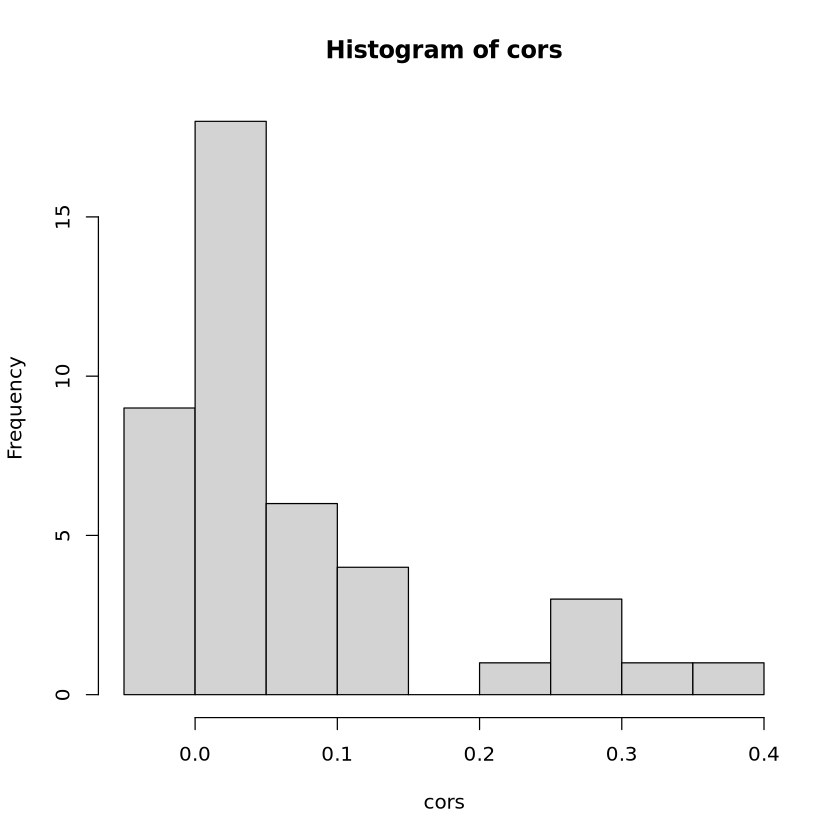

In [312]:
hist(cors)

In [313]:
mask <- Matrix::rowMeans(expr_RNA_filt) >= .2 
expr_RNA_filt_hi <- expr_RNA_filt[mask,]

genes_lower <- tolower(rownames(expr_RNA_filt_hi))

cors = c()

for (gene in genes_lower) {

    subset_RNA <- expr_RNA_filt_hi[tolower(rownames(expr_RNA_filt_hi)) %in% gene,]
    subset_ADT <- expr_ADT_filt[tolower(rownames(expr_ADT_filt)) %in% gene,]
    print(paste(toupper(gene), "cor =", cor(subset_ADT, subset_RNA)))
    cors <- c(cors, cor(subset_ADT, subset_RNA)) 

}

[1] "CXCR4 cor = 0.0251223076488247"
[1] "CD48 cor = 0.110512137977729"
[1] "CD36 cor = 0.00911242287558117"
[1] "CD38 cor = 0.0708980688516074"
[1] "CD8A cor = 0.255020243145647"
[1] "CD9 cor = 0.1342529146122"
[1] "CD69 cor = 0.110527532290588"
[1] "CD63 cor = 0.355545189692403"
[1] "JAML cor = 0.0519930995128024"
[1] "XCR1 cor = 0.0664688306978742"
[1] "CD68 cor = 0.0176635923985769"
[1] "CD83 cor = 0.0714704232921927"
[1] "CD86 cor = 0.344870399540769"
[1] "CD80 cor = 0.284163531201374"
[1] "CD200 cor = 0.287525619941256"
[1] "CD274 cor = 0.246040912637589"


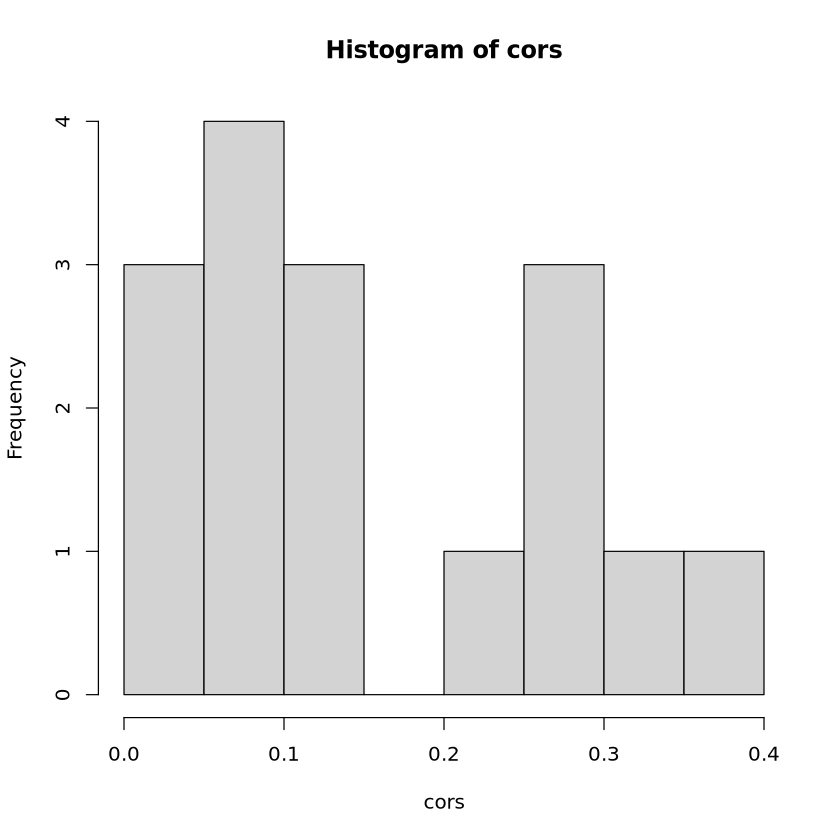

In [314]:
hist(cors)

In [315]:
shared_genes_df <- data.frame(Gene=rownames(expr_RNA_filt_hi))

write.csv(shared_genes_df, file="RNA_ADT_shared_genes_meanExpr>0.2.csv", row.names=FALSE, quote=FALSE)